# 09 · Localising the risk behaviors with open-vocabulary + segmentation

**Why this notebook.** Our 3 competition clips define **3 risk cases**:

| Clip | Risk case (our label) |
|---|---|
| tekno-01 | **SMOKING** (`cigarette`) |
| tekno-02 | **PHONE CALL** (`mobile phone`) |
| tekno-03 | **RECKLESS / SWERVING** (from the trajectory, not a cabin object) |

The trained `phone/safe` model has no `cigarette` class, so it could not localise
*smoking*. Here we use two foundation models — **off the live path** — purely to
**localise and auto-label** the behavior region so we can build a domain dataset:

- **YOLO-World** — open-vocabulary detection: prompt `cigarette` / `mobile phone` /
  `person` and it returns those concepts (no training needed).
- **SAM 2** — turns the driver detection into a **pixel mask** (precise region).

So the goal is NOT to run these live, but to **map our labels** (smoking / phone /
driver) onto the exact pixels — input for fine-tuning the fast model.

In [1]:
%matplotlib inline
import cv2, numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO, YOLOWorld, SAM
DEV = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
veh = YOLO("../backend/yolov8x.pt")
world = YOLOWorld("../backend/yolov8x-worldv2.pt")
sam = SAM("../backend/sam2_b.pt")
# our taxonomy: concept prompt -> project label + overlay color (RGB)
TAXO = {"cigarette": ("SMOKING", (255,60,60)), "mobile phone": ("PHONE CALL", (60,160,255))}
world.set_classes(list(TAXO) + ["person"])
print("loaded YOLO-World (concepts) + SAM2 (masks); labels:", [v[0] for v in TAXO.values()]+["DRIVER"])

C:\Users\USUARIO\Downloads\Nueva carpeta (35)\TeknoFest\backend\.venv\Lib\site-packages\clip\clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


loaded YOLO-World (concepts) + SAM2 (masks); labels: ['SMOKING', 'PHONE CALL', 'DRIVER']


### Localise + auto-label the behavior region (our labels, clean masks)

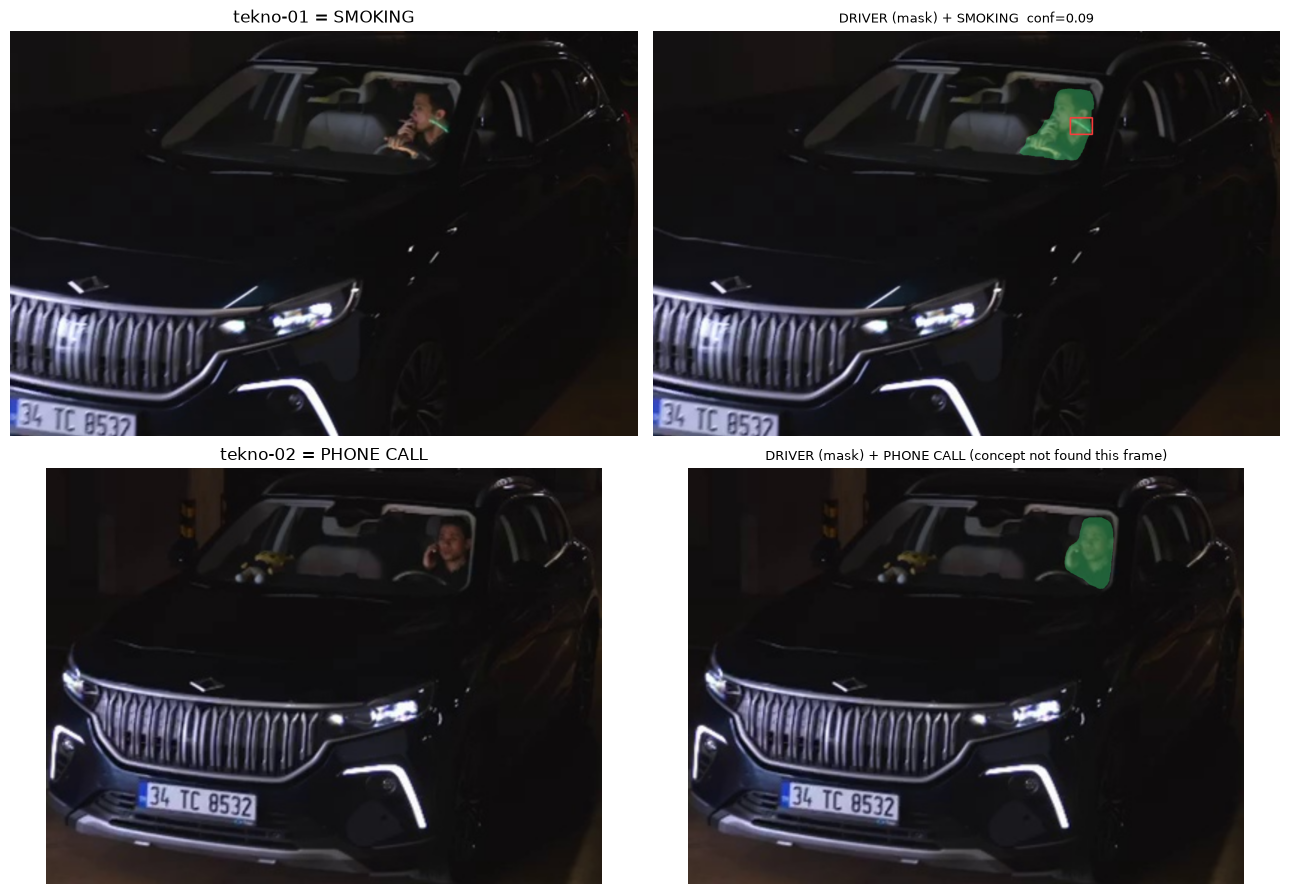

In [2]:
def analyze(name, expected_concept):
    img = cv2.imread(f"../tmp/frames/{name}.jpg")
    r = veh.predict(img, imgsz=512, conf=0.25, classes=[2,3,5,7], device=DEV, verbose=False)[0]
    b = max(r.boxes, key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
    x1,y1,x2,y2 = [int(v) for v in b.xyxy[0].tolist()]
    crop = cv2.resize(img[y1:y2, x1:x2], None, fx=4, fy=4)
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB); overlay = rgb.copy()
    w = world.predict(crop, imgsz=640, conf=0.02, device=DEV, verbose=False)[0]
    dets = [(world.names[int(d.cls)], float(d.conf), [int(v) for v in d.xyxy[0].tolist()]) for d in w.boxes]
    # 1) DRIVER mask via SAM2 on the best 'person' box
    persons = sorted([d for d in dets if d[0]=="person"], key=lambda x:-x[1])
    if persons:
        s = sam(crop, bboxes=[persons[0][2]], device=DEV, verbose=False)[0]
        if getattr(s,"masks",None) is not None:
            m = s.masks.data.cpu().numpy()[0].astype(bool)
            overlay[m] = (0.6*overlay[m] + 0.4*np.array([60,220,120])).astype(np.uint8)  # green = DRIVER
    # 2) the expected behavior concept box (our label)
    best = sorted([d for d in dets if d[0]==expected_concept], key=lambda x:-x[1])
    label, conf = TAXO[expected_concept]
    note = f"DRIVER (mask) + {label}"
    if best:
        bx = best[0][2]; col = TAXO[expected_concept][1]
        cv2.rectangle(overlay, (bx[0],bx[1]), (bx[2],bx[3]), col, 3)
        note += f"  conf={best[0][1]:.2f}"
    else:
        note += " (concept not found this frame)"
    return rgb, overlay, note

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (name, concept, title) in zip(axes, [("tekno-01-4s","cigarette","tekno-01 = SMOKING"),
                                              ("tekno-02-3s","mobile phone","tekno-02 = PHONE CALL")]):
    rgb, overlay, note = analyze(name, concept)
    row[0].imshow(rgb); row[0].set_title(title); row[0].axis("off")
    row[1].imshow(overlay); row[1].set_title(note, fontsize=9); row[1].axis("off")
plt.tight_layout(); plt.show()

## Conclusion

- **Purpose achieved:** YOLO-World maps **our project labels** onto the pixels —
  `cigarette → SMOKING`, `mobile phone → PHONE CALL` — and SAM 2 gives a clean
  **driver mask** (green). This is how we localise the behavior region to
  **auto-label** new frames for training, instead of hand-drawing every box.
- **Driver localisation is reliable**; the **behavior object** (cigarette/phone) is
  found with **low confidence** at 832×464 night footage — usable as an auto-label
  proposal that a human confirms, not as a final detector.
- **Third case — RECKLESS / SWERVING (tekno-03)** — is not a cabin object: it is
  derived from the **vehicle trajectory** (lateral movement of the tracked centre),
  handled in the detection/tracking pipeline (notebooks 01, 03), not here.
- **Use:** off-line auto-labelling → fine-tune the fast YOLOv8 (notebooks 03/07).
  These foundation models are too heavy for the live 10 FPS loop.